# 1. Business Understanding

In this project, I am not predicting demand. Instead, I focus on discovering hidden patterns across areas, price signals, and popularity signals, specifically within the FnB category in Kota Bogor. There are 5 core FnB categories in Google Maps that I used: restaurant, cafe/coffe shop, fast food, bakery, and bar.

I am using CRISP-DM framewrok to documenting this project as well as machine learning approach used in this case is unsupervised learning, as it allows the results to be described and interpreted more intuitively for most readers.

There are 3 main questions that will be addressed in this projects:
1. How can the FnB market in Kota Bogor be segmented and described?
2. Which areas in Bogor are over-saturated versus under-served in terms of FnB categories?
3. Which areas in Bogor have the highest-value customers in terms of willingness to pay?

Business values:
- ✅ Investors → where to open next
- ✅ FnB brands → pricing & positioning

Analytical Approach:
- Unit of analysis: Kecamatan (area-level)
- Method: Unsupervised learning (clustering)
- Framework: CRISP-DM
- Models: K-Means (interpretable & explainable)

# 2. Data Understanding

## 2.1 Load All Datasets

In [1]:
import pandas as pd

restaurant = pd.read_csv('/content/drive/MyDrive/Petalytix/FnB Market Segementation in Kota Bogor/restaurant.csv')
fast_food = pd.read_csv('/content/drive/MyDrive/Petalytix/FnB Market Segementation in Kota Bogor/fast_food.csv')
cafe = pd.read_csv('/content/drive/MyDrive/Petalytix/FnB Market Segementation in Kota Bogor/cafe.csv')
bakery = pd.read_csv('/content/drive/MyDrive/Petalytix/FnB Market Segementation in Kota Bogor/bakery.csv')
bar = pd.read_csv('/content/drive/MyDrive/Petalytix/FnB Market Segementation in Kota Bogor/bar.csv')

In [2]:
df = [restaurant, fast_food, cafe, bakery, bar]
df = pd.concat(df, ignore_index=True)

In [3]:
df.shape

(490, 27)

The datasets containing 500 rows with 27 columns. For every category I was using term "[Category] in Kota Bogor" (for example: "Restaurant in Kota Bogor") on Google Maps and grab the needed information using my scrapper engine. To be noted, when I search for specific category like Restaurant, the results can also show the other categories that close to the category that I am looking for like cafe, fast food, etc. So, later in this project remove duplicate rows will be neccessary to perform.  

## 2.2 Initial Exploration

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   url_id                  490 non-null    object 
 1   link                    490 non-null    object 
 2   location_name           490 non-null    object 
 3   category                487 non-null    object 
 4   address                 490 non-null    object 
 5   latitude                490 non-null    float64
 6   longitude               490 non-null    float64
 7   rating                  484 non-null    float64
 8   number_of_ratings       483 non-null    float64
 9   price_range_per_person  344 non-null    object 
 10  reported_by_people      282 non-null    float64
 11  range_price             282 non-null    object 
 12  percentage              282 non-null    object 
 13  monday_open             461 non-null    object 
 14  monday_close            461 non-null    ob

In [5]:
df.sample(n=3, random_state=52)

,url_id,link,location_name,category,address,latitude,longitude,rating,number_of_ratings,price_range_per_person,...,wednesday_open,wednesday_close,thursday_open,thursday_close,friday_open,friday_close,saturday_open,saturday_close,sunday_open,sunday_close
103,0x2e69c5cc57d59837:0x1701aafca849fbec,https://www.google.com/maps/place/Kedai+Kita/d...,Kedai Kita,Family restaurant,"Jl. Pangrango No.21, Babakan, Kecamatan Bogor ...",-6.590139,106.802813,4.5,13586.0,Rp 50.000-75.000,...,8.00 am,10.00 pm,8.00 am,10.00 pm,8.00 am,10.00 pm,8.00 am,10.00 pm,8.00 am,10.00 pm
437,0x2e69c5dd63b18d11:0x913b358084c47b83,https://www.google.com/maps/place/Ubeatz+Mall+...,Ubeatz Mall BTM Bogor,Karaoke bar,"Mall BTM Bogor, Jl. Ir. H. Juanda No.68 LT. 3,...",-6.604628,106.795693,4.8,89.0,Masterpiece Family Karaoke Signature Bogor · 4...,...,10.00 am,9.00 pm,10.00 am,9.00 pm,9.00 am,9.00 pm,9.00 am,9.00 pm,9.00 am,9.00 pm
485,0x2e69c5414b842371:0x1c4b5e7bb4acabde,https://www.google.com/maps/place/Stay+Low+Bar...,Stay Low Bar,Bar,"Jl. Siliwangi No.25 D, RT.02/RW.02, Sukasari, ...",-6.617367,106.811695,0.0,NaN,NaN,...,4.00,11.00 pm,4.00,11.00 pm,4.00,11.00 pm,4.00,11.00 pm,4.00,11.00 pm


# 3. Data Preparation

In [6]:
dfs = df.copy()

## 3.1 Unit Area for Analysis


### Kecamatan

Term "Kec." / "Kecamatan" is written in address

In [7]:
import re
import numpy as np

def extract_kecamatan(address):
  if pd.isna(address):
    return np.nan
  patterns = [
      r"(?:Kec\.\s*)([^,]+)",
      r"(?:kec\.\s*)([^,]+)",
      r"(?:Kecamatan\s*)([^,]+)",
      r"(?:kecamatan\s*)([^,]+)",
  ]
  for p in patterns:
    m = re.search(p, address, flags=re.IGNORECASE)
    if m:
      return m.group(1).strip()
  return np.nan

dfs['kecamatan'] = dfs['address'].apply(extract_kecamatan)

In [8]:
dfs['kecamatan'].unique()

array(['Bogor Utara', 'Bogor Tim.', 'Bogor Tengah', nan, 'Bogor Bar.',
       'Tanah Sereal', 'Ciomas', 'Bogor Sel.', 'Tanah', 'Bogor Tim',
       'Sukaraja', 'Cibinong', 'Babakan Madang'], dtype=object)

In [9]:
replacements = {
    'Bogor Bar.': 'Bogor Barat',
    'Bogor Tim.': 'Bogor Timur',
    'Bogor Tim': 'Bogor Timur',
    'Bogor Sel.': 'Bogor Selatan',
    'Tanah': 'Tanah Sareal',
    'Tanah Sereal': 'Tanah Sareal'
}

dfs['kecamatan'] = dfs['kecamatan'].replace(replacements)
dfs['kecamatan'].unique()

array(['Bogor Utara', 'Bogor Timur', 'Bogor Tengah', nan, 'Bogor Barat',
       'Tanah Sareal', 'Ciomas', 'Bogor Selatan', 'Sukaraja', 'Cibinong',
       'Babakan Madang'], dtype=object)

Term is not written in address

In [10]:
dfs[dfs['kecamatan'].isna()].shape

(65, 28)

77 rows contain null value in kecamatan

In [11]:
pd.set_option('display.max_colwidth', None)
dfs[dfs['kecamatan'].isna()]['address'].sample(n=5)

,address
486,"Achmad Adnawijaya St, Tegal Gundil, Bogor Utara, Bogor City, West Java"
479,"Golf Estate, Sukaraja, Bogor Raya, Bogor Regency, West Java 16710"
455,"Jl. Pakuan No.02, RT.02/RW.06, Tegallega, Kec, Kota Bogor, Jawa Barat 16129"
178,"CQFC+8WR, RT.01/RW.06, West Cilendek, Bogor Barat, Bogor City, West Java 16111"
457,"Bellanova Country Mall, Jl. MH. Thamrin No.Ruko 8, Sentul city, Babakan Madang, Bogor Regency, West Java 16810"


In [12]:
kecamatan_bogor = [
    'Bogor Utara', 'Bogor Timur', 'Bogor Tengah',
    'Bogor Barat', 'Tanah Sareal', 'Bogor Selatan'
]

def fill_missing_kecamatan(row):
    if pd.isna(row['kecamatan']):
        address_lower = str(row['address']).lower()
        for kc_name in kecamatan_bogor:
            kc_pattern = kc_name.lower().replace(' ', '\\s+')

            pattern = r'(?:^|[^\\w])' + kc_pattern + r'(?:$|[^\\w])'

            if re.search(pattern, address_lower, flags=re.IGNORECASE):
                return kc_name
    return row['kecamatan']

dfs['kecamatan'] = dfs.apply(fill_missing_kecamatan, axis=1)
dfs['kecamatan'] = dfs['kecamatan'].replace(replacements)


In [13]:
dfs[dfs['kecamatan'].isna()].shape

(18, 28)

19 rows left will null value in kecamatan. I will let them dropped.

Because in Kota Bogor there are only 6 kecamatan:
1. Bogor Selatan
2. Bogor Timur
3. Bogor Tengah
4. Bogor Barat
5. Bogor Utara
6. Tanah Sareal

The value of kecamatan which outside those six will be dropped later.

## 3.2 Price (Willingness to Pay/WTP)

### Standardize the Price Category

In [14]:
dfs['price_range_per_person'].unique()

array(['$$', 'Rp 1-25.000', '$$$', 'Rp 50.000-75.000',
       'Rp 50.000-100.000', 'Rp 25.000-75.000', 'Rp 25.000-50.000',
       'Rp 75.000-100.000', nan, 'Rp 1-50.000', 'Rp 250.000+', '$',
       'Masterpiece Family Karaoke Signature Bogor',
       'Tennis court BRP · 4.9 stars · 12 reviews · Gym',
       'Masterpiece Family Karaoke Signature Bogor · 4.3 stars · 1,845 reviews · Karaoke bar',
       'RP7+', 'Ahmad Rusdi', 'Masterpiece Ahmad Dani', '…', 'Rp 25-50',
       'Rp 1-25,000', 'RP4+'], dtype=object)

There are some noises data in the price_range_per_person column. Google Maps has a standard category for this:
1. Rp 1-25.000
2. Rp 25.000-50.000
3. Rp 50.000-75.000
4. Rp 75.000-100.000
5. Rp 1-50.000
6. Rp 25.000-75.000
7. Rp 50.000-100.000
8. Rp 250.000+
9. 💲
10. 💲💲
11. 💲💲💲
12. 💲💲💲💲

In [15]:
import numpy as np

valid_price_ranges = [
    'Rp 1-25.000', 'Rp 25.000-50.000', 'Rp 50.000-75.000',
    'Rp 75.000-100.000', 'Rp 1-50.000', 'Rp 25.000-75.000',
    'Rp 50.000-100.000', 'Rp 250.000+', '$', '$$', '$$$', '$$$$'
]

dfs.loc[~dfs['price_range_per_person'].isin(valid_price_ranges), 'price_range_per_person'] = np.nan

In [16]:
dfs['price_range_per_person'].unique()

array(['$$', 'Rp 1-25.000', '$$$', 'Rp 50.000-75.000',
       'Rp 50.000-100.000', 'Rp 25.000-75.000', 'Rp 25.000-50.000',
       'Rp 75.000-100.000', nan, 'Rp 1-50.000', 'Rp 250.000+', '$'],
      dtype=object)

In [17]:
print("Null Value in Price Range per Person: " + str(dfs['price_range_per_person'].isna().sum()) + " rows")

Null Value in Price Range per Person: 164 rows


### Conversion Dollar to Rupiah

There are around 32% of rows do not contain any price range per person information. Besides, there are price info in dollar format on the original page. So, I will convert them with this scheme:
* 💲 inexpensive --> Rp 1-25.000
* 💲💲 moderate --> Rp 25.000-50.000
* 💲💲💲 expensive --> Rp 50.000-100.000
* 💲💲💲💲 very expensive --> Rp 250.000+

In [18]:
price_map = {
    '$': 'Rp 1-25.000',
    '$$': 'Rp 25.000-50.000',
    '$$$': 'Rp 50.000-100.000',
    '$$$$': 'Rp 250.000+'
}

dfs['price_range_per_person'] = dfs['price_range_per_person'].replace(price_map)

### WtP Calculation

In the dataset, there are two columns that contain the votes of range price and its proportion. To be more precise, I will consider those two attributes to predict the willingness to pay of the customers.  

In [19]:
price = dfs[['url_id', 'kecamatan', 'category', 'price_range_per_person', 'range_price', 'percentage']].copy()
price.sample(n=5, random_state=52)

,url_id,kecamatan,category,price_range_per_person,range_price,percentage
103,0x2e69c5cc57d59837:0x1701aafca849fbec,Bogor Tengah,Family restaurant,Rp 50.000-75.000,"Rp 25.000-50.000, Rp 50.000-75.000, Rp 75.000-100.000, Rp 100.000-125.000","13%, 35%, 26%, 11%"
437,0x2e69c5dd63b18d11:0x913b358084c47b83,Bogor Tengah,Karaoke bar,NaN,NaN,NaN
485,0x2e69c5414b842371:0x1c4b5e7bb4acabde,Bogor Timur,Bar,NaN,NaN,NaN
202,0x2e69c5cf6fe1be11:0xe627bc0163f8be31,Bogor Utara,Restaurant,Rp 50.000-100.000,"Rp 1-50.000, Rp 50.000-100.000, Rp 100.000-150.000","15%, 57%, 18%"
274,0x2e69c50043bc9b37:0xfdb3a5ff7281f324,Tanah Sareal,Coffee shop,Rp 25.000-50.000,"Rp 1-25.000, Rp 25.000-50.000, Rp 50.000-75.000","9%, 75%, 16%"


As seen above, not all percentages have the total of 100%. I guess it's because they're outliers so Google do not show them. So, I will apply the normalized weight.



> 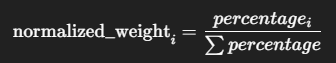



Then, to calculate the WTP there are 4 scenarios:
1. Using range_price & percentage (if applicable)
> 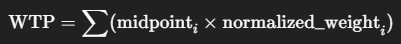

2. Using midpoint of price_range_per_person
> 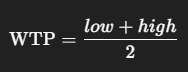


3. If NaN, imputation (median) considering "kecamatan" and "category"
4. If NaN, imputation (median) considering "category"
5. If NaN, imputation (median) considering "kecamatan"

In [20]:
def parse_buckets(range_price):
    return [b.strip() for b in range_price.split(",")]

In [21]:
def parse_percentages(percentage):
    return [
        float(p.replace("%","").strip())
        for p in percentage.split(",")
    ]

In [22]:
def bucket_to_midpoint(bucket):
    """
    'Rp 50.000-100.000' -> 75000
    """
    if pd.isna(bucket):
        return np.nan

    nums = re.findall(r"\d[\d\.]*", bucket)
    if len(nums) >= 2:
        low = int(nums[0].replace(".", ""))
        high = int(nums[1].replace(".", ""))
        return (low + high) / 2

    return np.nan

In [23]:
def weighted_wtp_from_buckets(range_price, percentage):
    if pd.isna(range_price) or pd.isna(percentage):
        return np.nan

    try:
        buckets = parse_buckets(range_price)
        weights = parse_percentages(percentage)

        if len(buckets) != len(weights):
            return np.nan

        mids = [bucket_to_midpoint(b) for b in buckets]
        if any(pd.isna(m) for m in mids):
            return np.nan

        total_weight = sum(weights)
        if total_weight == 0:
            return np.nan

        norm_weights = [w / total_weight for w in weights]

        return sum(m * w for m, w in zip(mids, norm_weights))

    except Exception as e:
        print("ERROR:", e)
        return np.nan

In [24]:
def parse_price_range_midpoint(s):
    if pd.isna(s):
        return np.nan

    nums = re.findall(r"\d[\d\.]*", str(s))
    if len(nums) >= 2:
        low = int(nums[0].replace(".", ""))
        high = int(nums[1].replace(".", ""))
        return (low + high) / 2
    elif len(nums) == 1:
        return int(nums[0].replace(".", ""))
    return np.nan

In [25]:
def compute_wtp(row):
    wtp_vote = weighted_wtp_from_buckets(
        row["range_price"],
        row["percentage"]
    )
    if not pd.isna(wtp_vote):
        return wtp_vote

    midpoint = parse_price_range_midpoint(row["price_range_per_person"])
    if not pd.isna(midpoint):
        return midpoint

    return np.nan

In [26]:
price["wtp"] = price.apply(compute_wtp, axis=1)

In [27]:
price.sample(n=5, random_state=52)

,url_id,kecamatan,category,price_range_per_person,range_price,percentage,wtp
103,0x2e69c5cc57d59837:0x1701aafca849fbec,Bogor Tengah,Family restaurant,Rp 50.000-75.000,"Rp 25.000-50.000, Rp 50.000-75.000, Rp 75.000-100.000, Rp 100.000-125.000","13%, 35%, 26%, 11%",72794.117647
437,0x2e69c5dd63b18d11:0x913b358084c47b83,Bogor Tengah,Karaoke bar,NaN,NaN,NaN,NaN
485,0x2e69c5414b842371:0x1c4b5e7bb4acabde,Bogor Timur,Bar,NaN,NaN,NaN,NaN
202,0x2e69c5cf6fe1be11:0xe627bc0163f8be31,Bogor Utara,Restaurant,Rp 50.000-100.000,"Rp 1-50.000, Rp 50.000-100.000, Rp 100.000-150.000","15%, 57%, 18%",76666.750000
274,0x2e69c50043bc9b37:0xfdb3a5ff7281f324,Tanah Sareal,Coffee shop,Rp 25.000-50.000,"Rp 1-25.000, Rp 25.000-50.000, Rp 50.000-75.000","9%, 75%, 16%",39250.045000


In [28]:
print("Null Value in Price Range per Person: " + str(price['wtp'].isna().sum()) + " rows")

Null Value in Price Range per Person: 164 rows


### Imputation

158 (~30%) rows contain missing value in _price_range_per_person_. The imputation approach considering its kecamatan and category will be implemented to fill the missing values.

In [29]:
price['wtp'] = price.groupby(['kecamatan', 'category'])['wtp'].transform(lambda x: x.fillna(x.median()))
price['wtp'] = price.groupby(['category'])['wtp'].transform(lambda x: x.fillna(x.median())) #if still null only considering category
price['wtp'] = price.groupby(['kecamatan'])['wtp'].transform(lambda x: x.fillna(x.median())) #if still null only use kecamatan

In [30]:
print("Null Value in Price Range per Person: " + str(price['wtp'].isna().sum()) + " rows")

Null Value in Price Range per Person: 18 rows


In [31]:
price.sample(n=5, random_state=52)

,url_id,kecamatan,category,price_range_per_person,range_price,percentage,wtp
103,0x2e69c5cc57d59837:0x1701aafca849fbec,Bogor Tengah,Family restaurant,Rp 50.000-75.000,"Rp 25.000-50.000, Rp 50.000-75.000, Rp 75.000-100.000, Rp 100.000-125.000","13%, 35%, 26%, 11%",72794.117647
437,0x2e69c5dd63b18d11:0x913b358084c47b83,Bogor Tengah,Karaoke bar,NaN,NaN,NaN,250000.000000
485,0x2e69c5414b842371:0x1c4b5e7bb4acabde,Bogor Timur,Bar,NaN,NaN,NaN,143750.000000
202,0x2e69c5cf6fe1be11:0xe627bc0163f8be31,Bogor Utara,Restaurant,Rp 50.000-100.000,"Rp 1-50.000, Rp 50.000-100.000, Rp 100.000-150.000","15%, 57%, 18%",76666.750000
274,0x2e69c50043bc9b37:0xfdb3a5ff7281f324,Tanah Sareal,Coffee shop,Rp 25.000-50.000,"Rp 1-25.000, Rp 25.000-50.000, Rp 50.000-75.000","9%, 75%, 16%",39250.045000


In [32]:
dfs = pd.concat([dfs, price[['wtp']]], axis=1)

## 3.3 Feature Selection and Engineering

### Category Mapping

In [33]:
df_clean = dfs.copy()

In [34]:
CATEGORY_MAP = {
    # RESTAURANT
    "Sundanese restaurant": "restaurant",
    "Family restaurant": "restaurant",
    "Japanese restaurant": "restaurant",
    "Soup restaurant": "restaurant",
    "Indonesian restaurant": "restaurant",
    "Restaurant": "restaurant",
    "Steak house": "restaurant",
    "Dessert restaurant": "restaurant",
    "Pizza restaurant": "restaurant",
    "Soto restaurant": "restaurant",
    "Korean restaurant": "restaurant",
    "Ramen restaurant": "restaurant",
    "Dim sum restaurant": "restaurant",
    "Javanese restaurant": "restaurant",
    "Nasi goreng restaurant": "restaurant",
    "Buffet restaurant": "restaurant",
    "Pempek restaurant": "restaurant",
    "Diner": "restaurant",
    "Batak restaurant": "restaurant",
    "Padang restaurant": "restaurant",
    "Chinese restaurant": "restaurant",
    "Brunch restaurant": "restaurant",
    "Chicken restaurant": "restaurant",
    "Asian restaurant": "restaurant",
    "Italian restaurant": "restaurant",
    "Bavarian restaurant": "restaurant",
    "Sushi restaurant": "restaurant",
    "Halal restaurant": "restaurant",
    "Turkish restaurant": "restaurant",
    "Taiwanese restaurant": "restaurant",
    "Health food restaurant": "restaurant",
    "Pasta shop": "restaurant",
    "Tofu restaurant": "restaurant",
    "Chicken shop": "restaurant",
    "Soup kitchen": "restaurant",
    "Hawker stall": "restaurant",

    # FAST FOOD
    "Fast food restaurant": "fast_food",
    "Hamburger restaurant": "fast_food",
    "Chicken wings restaurant": "fast_food",
    "Fried chicken takeaway": "fast_food",
    "Kebab shop": "fast_food",
    "Noodle shop": "fast_food",
    "Soup shop": "fast_food",
    "Food court": "fast_food",
    "Deli": "fast_food",
    "Kiosk": "fast_food",
    "Snack bar": "fast_food",

    # CAFE
    "Cafe": "cafe",
    "Coffee shop": "cafe",
    "Coffee roasters": "cafe",
    "Coffee store": "cafe",

    # BAKERY
    "Bakery": "bakery",
    "Cake shop": "bakery",
    "Pastry shop": "bakery",
    "Donut shop": "bakery",
    "Cookie shop": "bakery",

    # BAR
    "Bar": "bar",
    "Karaoke bar": "bar",
    "Live music bar": "bar",
    "Lounge": "bar",
    "Wine bar": "bar",
    "Pub": "bar",
    "Sports bar": "bar",
    "Dart bar": "bar",
    "Wine store": "bar",
}


In [35]:
df_clean["main_category"] = df_clean["category"].map(CATEGORY_MAP)

In [36]:
df_clean["main_category"].unique()

array(['restaurant', 'fast_food', 'cafe', 'bakery', 'bar', nan],
      dtype=object)

In [37]:
df_clean["main_category"].value_counts()

,count
main_category,
restaurant,113
cafe,108
bakery,100
fast_food,90
bar,73


## 3.4 Filtering Rows & Aggregation

### Rows Cleaning

In [38]:
df_clean = df_clean[['url_id', 'location_name', 'main_category', 'latitude', 'longitude',
                     'rating', 'number_of_ratings',
                     'price_range_per_person', 'kecamatan', 'wtp']]

In [39]:
df_clean.sample(n=5, random_state=52)

,url_id,location_name,main_category,latitude,longitude,rating,number_of_ratings,price_range_per_person,kecamatan,wtp
103,0x2e69c5cc57d59837:0x1701aafca849fbec,Kedai Kita,restaurant,-6.590139,106.802813,4.5,13586.0,Rp 50.000-75.000,Bogor Tengah,72794.117647
437,0x2e69c5dd63b18d11:0x913b358084c47b83,Ubeatz Mall BTM Bogor,bar,-6.604628,106.795693,4.8,89.0,NaN,Bogor Tengah,250000.000000
485,0x2e69c5414b842371:0x1c4b5e7bb4acabde,Stay Low Bar,bar,-6.617367,106.811695,0.0,NaN,NaN,Bogor Timur,143750.000000
202,0x2e69c5cf6fe1be11:0xe627bc0163f8be31,Agreya Coffee Bogor,restaurant,-6.592460,106.816228,4.8,4317.0,Rp 50.000-100.000,Bogor Utara,76666.750000
274,0x2e69c50043bc9b37:0xfdb3a5ff7281f324,Tanda jadi coffee,cafe,-6.579469,106.793987,4.9,91.0,Rp 25.000-50.000,Tanah Sareal,39250.045000


Final cleaning:
- Remove duplicates
- Drop places outside Kota Bogor
- Drop places without category

In [40]:
df_clean.drop_duplicates(subset='url_id', keep='first', inplace=True)

In [41]:
df_clean = df_clean[df_clean['kecamatan'].isin(kecamatan_bogor)]

In [42]:
df_clean = df_clean.dropna(subset=['main_category'])

In [43]:
df_clean.shape

(424, 10)

Now the dataset has 424 rows (~85%)

### Aggregation

In [44]:
df_agg = df_clean.copy()

In [45]:
area = df_agg.groupby("kecamatan").agg(
    total_outlets=("url_id", "count"),
    avg_rating=("rating", "mean"),
    total_reviews=("number_of_ratings", "sum"),
    avg_wtp=("wtp", "mean")
).reset_index()

In [46]:
area

,kecamatan,total_outlets,avg_rating,total_reviews,avg_wtp
0,Bogor Barat,61,4.575410,19688.0,40836.115155
1,Bogor Selatan,11,4.718182,1686.0,79652.373497
2,Bogor Tengah,155,4.657516,150279.0,55564.819007
3,Bogor Timur,52,4.496078,138557.0,77155.872529
4,Bogor Utara,47,4.693478,97184.0,67688.566175
5,Tanah Sareal,98,4.622680,81806.0,40419.422002


In [47]:
mix = pd.crosstab(df_agg["kecamatan"], df_agg["main_category"]).reset_index()

In [48]:
mix

main_category,kecamatan,bakery,bar,cafe,fast_food,restaurant
0,Bogor Barat,17,3,11,18,12
1,Bogor Selatan,5,5,0,1,0
2,Bogor Tengah,33,16,39,26,41
3,Bogor Timur,12,22,2,3,13
4,Bogor Utara,8,13,10,6,10
5,Tanah Sareal,17,5,32,27,17


In [49]:
area = area.merge(mix, on="kecamatan", how="left").fillna(0)

Since there are five main categories, I want to take into account the diversities for each area to sharpen the analysis. The metric Shannon Entropy (normalized) was used to measure the diversity score. So, here is how this intuition works:

> 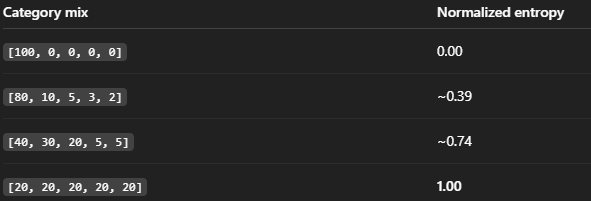



In [50]:
def normalized_entropy(counts):
    counts = np.array(counts, dtype=float)

    if counts.sum() == 0:
        return 0.0

    p = counts / counts.sum()
    p = p[p > 0]  # avoid log(0)

    entropy = -np.sum(p * np.log(p))
    max_entropy = np.log(len(counts))

    return entropy / max_entropy

In [51]:
category_cols = ["restaurant", "fast_food", "cafe", "bakery", "bar"]

area["diversity_score"] = area[category_cols].apply(
    lambda row: normalized_entropy(row.values),
    axis=1
)

In [52]:
area

,kecamatan,total_outlets,avg_rating,total_reviews,avg_wtp,bakery,bar,cafe,fast_food,restaurant,diversity_score
0,Bogor Barat,61,4.575410,19688.0,40836.115155,17,3,11,18,12,0.927729
1,Bogor Selatan,11,4.718182,1686.0,79652.373497,5,5,0,1,0,0.580805
2,Bogor Tengah,155,4.657516,150279.0,55564.819007,33,16,39,26,41,0.970641
3,Bogor Timur,52,4.496078,138557.0,77155.872529,12,22,2,3,13,0.831829
4,Bogor Utara,47,4.693478,97184.0,67688.566175,8,13,10,6,10,0.980583
5,Tanah Sareal,98,4.622680,81806.0,40419.422002,17,5,32,27,17,0.919698


In [53]:
area["avg_reviews_per_outlet"] = area["total_reviews"] / area["total_outlets"]

In [54]:
area

,kecamatan,total_outlets,avg_rating,total_reviews,avg_wtp,bakery,bar,cafe,fast_food,restaurant,diversity_score,avg_reviews_per_outlet
0,Bogor Barat,61,4.575410,19688.0,40836.115155,17,3,11,18,12,0.927729,322.754098
1,Bogor Selatan,11,4.718182,1686.0,79652.373497,5,5,0,1,0,0.580805,153.272727
2,Bogor Tengah,155,4.657516,150279.0,55564.819007,33,16,39,26,41,0.970641,969.541935
3,Bogor Timur,52,4.496078,138557.0,77155.872529,12,22,2,3,13,0.831829,2664.557692
4,Bogor Utara,47,4.693478,97184.0,67688.566175,8,13,10,6,10,0.980583,2067.744681
5,Tanah Sareal,98,4.622680,81806.0,40419.422002,17,5,32,27,17,0.919698,834.755102


# 4. Modeling

## 4.1 Feature Selection

In [55]:
features = [
    "total_outlets",
    "avg_rating",
    "total_reviews",
    "avg_wtp",
    "avg_reviews_per_outlet",
    "diversity_score",
    "restaurant",
    "fast_food",
    "cafe",
    "bakery",
    "bar",
]

## 4.2 Feature Scaling

In [56]:
from sklearn.preprocessing import StandardScaler

# Since K-Means sensitive to distance and the dataset contain outliers, skewness, and open-ended ranges, StandardScaler would be best to normalize the distribution of the data instead of MinMaxScaler.

X = area[features].replace([np.inf, -np.inf], np.nan).fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4.3 Optimal Cluster Selection

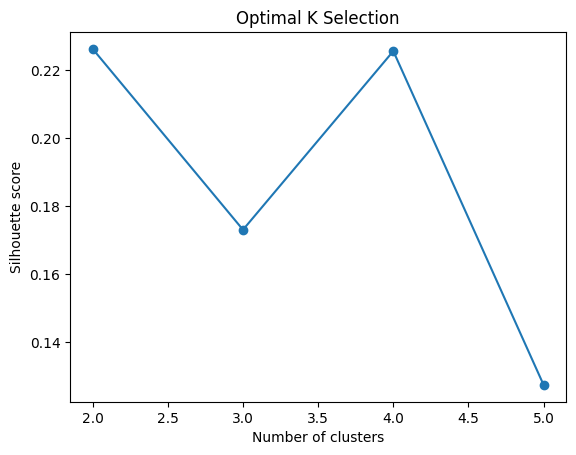

In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []
K = range(2, 6)

for k in K:
  km = KMeans(n_clusters=k, random_state=52, n_init='auto')
  labels = km.fit_predict(X_scaled)
  scores.append(silhouette_score(X_scaled, labels))

plt.plot(K, scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Optimal K Selection")
plt.show()

This Silhoutte score [-1 to 1] reflects how similar a data point to its own cluster (cohesion) vs other clusters (separation).
 * +1 well separated & defined
 * ~0 clusters overlap
 * -1 misclassified

What can be interpreted from this graph:
- K = 2 strong separation but too coarse (business-wise meaningless)
- K = 3 acceptable but some structure lost
- **K = 4 [SS ~0.23] best trade off between structure and insight (business usefulness)**
- K = 5 over-fragmented

_in real-world geospatial data, Silhoutte Scores between 0.2-0.4 are often normal and acceptable_
> ref: https://pmc.ncbi.nlm.nih.gov/articles/PMC12466245/

## 4.4 Final Model

In [58]:
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=52, n_init='auto')
area['cluster'] = kmeans.fit_predict(X_scaled)

In [59]:
area

,kecamatan,total_outlets,avg_rating,total_reviews,avg_wtp,bakery,bar,cafe,fast_food,restaurant,diversity_score,avg_reviews_per_outlet,cluster
0,Bogor Barat,61,4.575410,19688.0,40836.115155,17,3,11,18,12,0.927729,322.754098,2
1,Bogor Selatan,11,4.718182,1686.0,79652.373497,5,5,0,1,0,0.580805,153.272727,3
2,Bogor Tengah,155,4.657516,150279.0,55564.819007,33,16,39,26,41,0.970641,969.541935,1
3,Bogor Timur,52,4.496078,138557.0,77155.872529,12,22,2,3,13,0.831829,2664.557692,0
4,Bogor Utara,47,4.693478,97184.0,67688.566175,8,13,10,6,10,0.980583,2067.744681,0
5,Tanah Sareal,98,4.622680,81806.0,40419.422002,17,5,32,27,17,0.919698,834.755102,2


# 5. Evaluation (Business Interpretation)

## 5.1 Cluster Profiles

In [60]:
cluster_profile = area.groupby('cluster')[features].mean().round(2)
cluster_profile

,total_outlets,avg_rating,total_reviews,avg_wtp,avg_reviews_per_outlet,diversity_score,restaurant,fast_food,cafe,bakery,bar
cluster,,,,,,,,,,,
0,49.5,4.59,117870.5,72422.22,2366.15,0.91,11.5,4.5,6.0,10.0,17.5
1,155.0,4.66,150279.0,55564.82,969.54,0.97,41.0,26.0,39.0,33.0,16.0
2,79.5,4.60,50747.0,40627.77,578.75,0.92,14.5,22.5,21.5,17.0,4.0
3,11.0,4.72,1686.0,79652.37,153.27,0.58,0.0,1.0,0.0,5.0,5.0


**Key Business Metrics:**
1. Supply → total_outlets
2. Demand → total_reviews, avg_reviews_per_outlet
3. Quality → avg_rating
4. Spending Power → avg_wtp
5. Market Diversity → diversity_score

## Q1. How can the FnB market in Kota Bogor be segmented and described?

**Interpretation**:

> Cluster 0: Premium-Balanced Lifestyle
- Supply: Medium (~50 outlets)
- **Demand: Very High-Intense (~2.3k+ reviews/outlet)**
- **Spending Power: Very High (WtP ~72k per person)**
- Market Diversity: High (~0.91)

**Typical: Destination dining areas, Strong UVP outlets, Highly engaged consumers**

> Cluster 1: Mainstream FnB Hub
- **Supply: Highest (155 outlets)**
- **Demand: Highest (150k+ total reviews)**
- Spending Power: Medium (WtP ~55k per person)
- **Market Diversity: Highest (strong presence across all categories ~0.97)**

**Typical: Central area, Driven by mall and arterial-roads, Established commercial zones**

> Cluster 2: Active Mid-Tier
- Supply: High (~80 outlets)
- Demand: Medium (~600+ reviews/outlet)
- Spending Power: Very Low (WtP ~40k per person)
- Market Diversity: High (~0.92)

**Typical: Residential-commercial transition area, Daily consumption hubs, Price conscious customers**

> Cluster 3: Niche High-End
- Supply: Very Low (~11 outlets)
- Demand: Very Low (~150+ reviews/outlet)
- Spending Power: Highest (WtP ~79k per person)
- Market Diversity: Very Low (~0.58)

**Typical: Upper-middle residential areas, Quality consious customers, Under-served consumers**

## Q2. Which areas in Bogor are over-saturated versus under-served in terms of FnB categories?

* Over-saturated → Cluster 1 [Bogor Tengah]
* Under-served → Cluster 3 [Bogor Selatan]
* Competitive but healthy → Cluster 0 [Bogor Utara & Bogor Timur]
* Balanced mass-market → Cluster 2 [Bogor Barat & Tanah Sareal]




## Q3. Which areas in Bogor have the highest-value customers in terms of willingness to pay?

* Cluster 3 → Highly potential consumers but low supply
* Cluster 0 → Premium area that makes consumers to adjust on their own
* Cluster 1 → High volume and solid WtP
* Cluster 2 → Price-sensitive area

# 6. Deploy (Visualization)

In [70]:
import numpy as np
import pandas as pd
import folium
from folium.plugins import HeatMap

df_map = df_clean.merge(area[["kecamatan","cluster"]], on="kecamatan", how="left")

# --- Clean coords ---
df_map = df_map.copy()
df_map["latitude"] = pd.to_numeric(df_map["latitude"], errors="coerce")
df_map["longitude"] = pd.to_numeric(df_map["longitude"], errors="coerce")
df_map = df_map.dropna(subset=["latitude","longitude"])

# --- Clean WTP ---
df_map["wtp"] = pd.to_numeric(df_map["wtp"], errors="coerce")
cap = df_map["wtp"].quantile(0.99)
df_map["wtp_capped"] = df_map["wtp"].clip(upper=cap)

# --- Cluster colors (adjust if needed) ---
CLUSTER_INFO = {
    0: {"name": "Premium-Balanced Lifestyle", "color": "green"},
    1: {"name": "Mainstream FnB Hub", "color": "orange"},
    2: {"name": "Active Mid-Tier", "color": "blue"},
    3: {"name": "Niche High-End", "color": "red"},
}

# --- Helper: build heat points for a df slice ---
def build_heat_points(df_slice, weight_col="wtp_capped"):
    tmp = df_slice.dropna(subset=["latitude","longitude",weight_col]).copy()
    if len(tmp) == 0:
        return []
    w = tmp[weight_col].astype(float)
    w_norm = (w - w.min()) / (w.max() - w.min() + 1e-9)  # normalize 0..1
    tmp["w_norm"] = w_norm
    return tmp[["latitude","longitude","w_norm"]].values.tolist()

# --- Create base map (Bogor safe center) ---
m = folium.Map(location=[-6.595, 106.816], zoom_start=12, tiles="OpenStreetMap")

# =========================
# Layer 1: Cluster dots
# =========================
fg_clusters = folium.FeatureGroup(name="FnB Market Clusters (Dots)", show=True)

dot_df = df_map.dropna(subset=["cluster"]).copy()
dot_df["cluster"] = pd.to_numeric(dot_df["cluster"], errors="coerce")
dot_df = dot_df.dropna(subset=["cluster"])
dot_df["cluster"] = dot_df["cluster"].astype(int)

for _, r in dot_df.iterrows():
    info = CLUSTER_INFO.get(int(r["cluster"]), {"color": "gray", "name": "Unknown"})
    folium.CircleMarker(
        location=[r["latitude"], r["longitude"]],
        radius=3,
        color=info["color"],
        fill=True,
        fill_opacity=0.7,
        popup=f'{r["location_name"]} | {r["main_category"]} | {round(r["wtp"],0)}',
    ).add_to(fg_clusters)

fg_clusters.add_to(m)

# =========================
# Layers 2+: WTP Heatmap by category
# =========================
categories = ["restaurant", "fast_food", "cafe", "bakery", "bar"]

for cat in categories:
    df_cat = df_map[df_map["main_category"] == cat]
    fg = folium.FeatureGroup(name=f"WTP Heatmap – {cat.replace('_',' ').title()}", show=False)

    HeatMap(
        build_heat_points(df_cat),
        radius=20,
        blur=25,
        min_opacity=0.30
    ).add_to(fg)

    fg.add_to(m)

# Controls
folium.LayerControl(collapsed=False).add_to(m)

legend_html = """
<div style="
    position: fixed;
    bottom: 50px;
    left: 50px;
    width: 260px;
    background-color: white;
    border:2px solid grey;
    z-index:9999;
    font-size:14px;
    padding: 10px;
">
<b>FnB Market Clusters – Bogor</b><br>
<span style="color:green;">●</span> Premium-Balanced Lifestyle<br>
<span style="color:orange;">●</span> Mainstream FnB Hub<br>
<span style="color:blue;">●</span> Active Mid-Tier<br>
<span style="color:red;">●</span> Niche High-End
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))


m
